# **Importando as Bibliotecas**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# **Carregando o Dataset**

In [2]:
bcancer = load_breast_cancer()

In [3]:
bcancer

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

# **Aplicando o PCA, explicando os 80% da variancia e verificando a quantidade de componentes**

In [4]:
# Separando as Features do Target
X = bcancer['data']
y = bcancer['target']

In [5]:
# Dividindo em Train Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [6]:
# Normalização dos dados por padronização
sc = StandardScaler()
X_norm = sc.fit_transform(X_train)
X_test_norm = sc.transform(X_test)

In [7]:
# Aplicando o PCA
PCA_model = PCA(n_components=.80)
X_train_pca = PCA_model.fit_transform(X_norm)
X_test_pca = PCA_model.transform(X_test_norm)

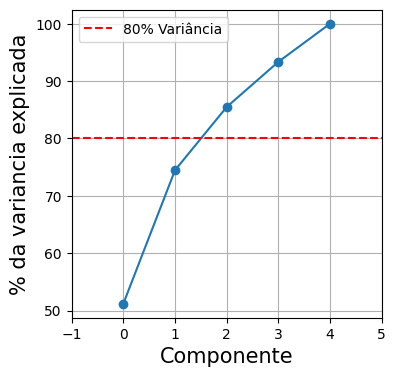

In [8]:
# Análise dos Componentes

def component_analysis(e, plot='none'):
    varexp = 100* e/e.sum()
    cumvarexp = np.cumsum(varexp)

    # Plotando a explicação da variância
    if (plot=='varexp'):
        plt.figure(figsize = (4,4))
        plt.plot(cumvarexp, '-o')
        plt.xlabel('Componente', fontsize = 15)
        plt.ylabel('% da variancia explicada', fontsize = 15)
        plt.axhline(y=80, color='r', linestyle='--', label='80% Variância')
        plt.legend(loc='best')
        plt.grid(True)
        xint = []
        locs, labels = plt.xticks()
        for each in locs:
            xint.append(int(each))
        plt.xticks(xint)

    plt.show()

# Visualização - plot=['varexp']

# Obtendo as taxas de variância explicada do modelo PCA
explained_variance = PCA_model.explained_variance_

# Chamando a função com as taxas de variância explicada
component_analysis(explained_variance, plot='varexp')

In [9]:
# Variância explicada acumulada
explained_variance = np.cumsum(PCA_model.explained_variance_ratio_)

In [10]:
# Determinar o número de componentes para 80% de variância
n_components_80 = np.argmax(explained_variance >= 0.80) + 1
print(f"Número de componentes para 80% de variância: {n_components_80}")

Número de componentes para 80% de variância: 5


# **Aplicando o GRID , verificando os melhores parametros e visualizando o Classification Report**

In [11]:
# Defini-se os ranges dos parametros
param_grid = {'C': [0.1, 1, 10, 100],
              'degree': [3, 5],
              'gamma': [0.1, 1, 10, 100],
              'kernel': ['rbf', 'linear']
}


In [12]:
# Instancia o GridSearch com o classificador
grid_svm = GridSearchCV(SVC(), param_grid, verbose = 3)

In [13]:
# Faz-se o fit
grid_svm.fit(X_train_pca, y_train)

Fitting 5 folds for each of 64 candidates, totalling 320 fits
[CV 1/5] END C=0.1, degree=3, gamma=0.1, kernel=rbf;, score=0.923 total time=   0.0s
[CV 2/5] END C=0.1, degree=3, gamma=0.1, kernel=rbf;, score=0.967 total time=   0.0s
[CV 3/5] END C=0.1, degree=3, gamma=0.1, kernel=rbf;, score=0.923 total time=   0.0s
[CV 4/5] END C=0.1, degree=3, gamma=0.1, kernel=rbf;, score=0.956 total time=   0.0s
[CV 5/5] END C=0.1, degree=3, gamma=0.1, kernel=rbf;, score=0.989 total time=   0.0s
[CV 1/5] END C=0.1, degree=3, gamma=0.1, kernel=linear;, score=0.967 total time=   0.0s
[CV 2/5] END C=0.1, degree=3, gamma=0.1, kernel=linear;, score=0.967 total time=   0.0s
[CV 3/5] END C=0.1, degree=3, gamma=0.1, kernel=linear;, score=0.945 total time=   0.0s
[CV 4/5] END C=0.1, degree=3, gamma=0.1, kernel=linear;, score=0.978 total time=   0.0s
[CV 5/5] END C=0.1, degree=3, gamma=0.1, kernel=linear;, score=0.989 total time=   0.0s
[CV 1/5] END C=0.1, degree=3, gamma=1, kernel=rbf;, score=0.637 total tim

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100], 'degree': [3, 5],
                         'gamma': [0.1, 1, 10, 100],
                         'kernel': ['rbf', 'linear']},
             verbose=3)

In [14]:
# Visualizando os melhores estimadores
grid_svm.best_estimator_

SVC(C=10, gamma=0.1, kernel='linear')

In [15]:
# Visualizando o modelo depois do tunning de hiper parametro
grid_svm.predict(X_test_pca)

array([0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 0, 0, 1])

In [16]:
# Visualizando os melhores parametros
grid_svm.best_params_

{'C': 10, 'degree': 3, 'gamma': 0.1, 'kernel': 'linear'}

In [17]:
# Visualizando o melhor score
grid_svm.best_score_

0.9758241758241759

In [18]:
# Visualizando o Classification Report
print(classification_report(y_test, grid_svm.predict(X_test_pca)))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95        47
           1       0.96      0.97      0.96        67

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

